In [1]:
import os
import sys
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.interpolate import Akima1DInterpolator
import pandas as pd
from PIL import Image
from glob import glob
from tools.fdm.src import fdm3Blom, mfgrid
from tools.etc import color_cycler, logo, descr, pickleto, picklefrom
from tools.analytic.nsec1 import Nsec1
from mf6lab.Projects.ARK_RWS.src import ARK_tools as atools
from importlib import reload

print("=== Current Session ===")
print("os.getcwd():", os.getcwd())
print("sys.executable: ", sys.executable)
print("sys.path:")
for p in sys.path:
    print(p)
print("=======================")

NOTEBOOK_NAME = 'explore_data.ipynb'
print(f"NOTEBOOK_NAME = '{NOTEBOOK_NAME}'")

# --- From atools
dirs = atools.dirs
point_line_distance = atools.point_line_distance
point_polyline_distance = atools.point_polyline_distance
muT_mu10C = atools.muT_mu10C

print("Project directory namespace:")
descr(dirs)

# --- dtypes for boundary conditions of Fdm3
dtypes = fdm3Blom.Fdm3.dtypes


loading mfpath.py

os.getcwd(): /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/notebooks
sys.executable =  /Users/Theo/Development/python/mf6_tools/mf6lab/.venv/bin/python
ARGV ['/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/ipykernel_launcher.py', '--f=/Users/Theo/Library/Jupyter/runtime/kernel-v34b9715a49f6898aebfd3b0ab1761b606c55ba600.json']
sys.path:
/Users/Theo/GRWMODELS/python/tools
./modules/
/Users/Theo/GRWMODELS/python/bootstraps
/Library/Frameworks/Python.framework/Versions/3.13/lib/python313.zip
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload

/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages
__editable__.mf6lab-0.1.finder.__path_hook__
__editable__.tools-0.1.finder.__path_hook__

=== Current Session ===
os.getcwd(): /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/notebooks
sys

# Plot the piezometers on the maps to show their positions in context

In [2]:
pbxy = atools.Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')
pxy = np.asarray(pbxy.data.loc[:, ['x', 'y']])

In [3]:
maps = [os.path.basename(p) for p in glob(os.path.join(dirs.pb_imag, 'map*.png'))]
maps

['map_peilgeb_125629_132885_469223_479409.png',
 'map_pb_tauw_Z_126306_130855_466541_473084.png',
 'map_dwarsdsn_Deltares_124941_134986_464597_481509__hart_129736_475371.png',
 'map_pb_tauw_N_127302_131907_472471_479078.png']

# Observation well locations on map

In [33]:
wellen_deltares_df = pd.read_csv(os.path.join(dirs.data, 'wellen_deltares.csv'))
wellen = np.vstack((wellen_deltares_df['x'], wellen_deltares_df['y'])).T
dist = point_polyline_distance(wellen, hartlijn_ARK)
wellen_deltares_df['dist'] = dist[0].round(0)
wellen_deltares_df['xhit'] = dist[1][:,0]
wellen_deltares_df['yhit'] = dist[1][:,1]
wellen_deltares_df
pickleto(wellen_deltares_df, os.path.join(dirs.data, 'wellen_deltares_df.pkl'))

Pickled <function basename at 0x107c7f9c0> --> /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/wellen_deltares_df.pkl


In [32]:
from inspect import signature
signature(pickleto)

<Signature (var: Any, path: str)>

Loaded <function basename at 0x107c7f9c0> <-- /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/wellen_deltares_df.pkl
Loaded <function basename at 0x107c7f9c0> <-- /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/hartlijn_ARK.pkl


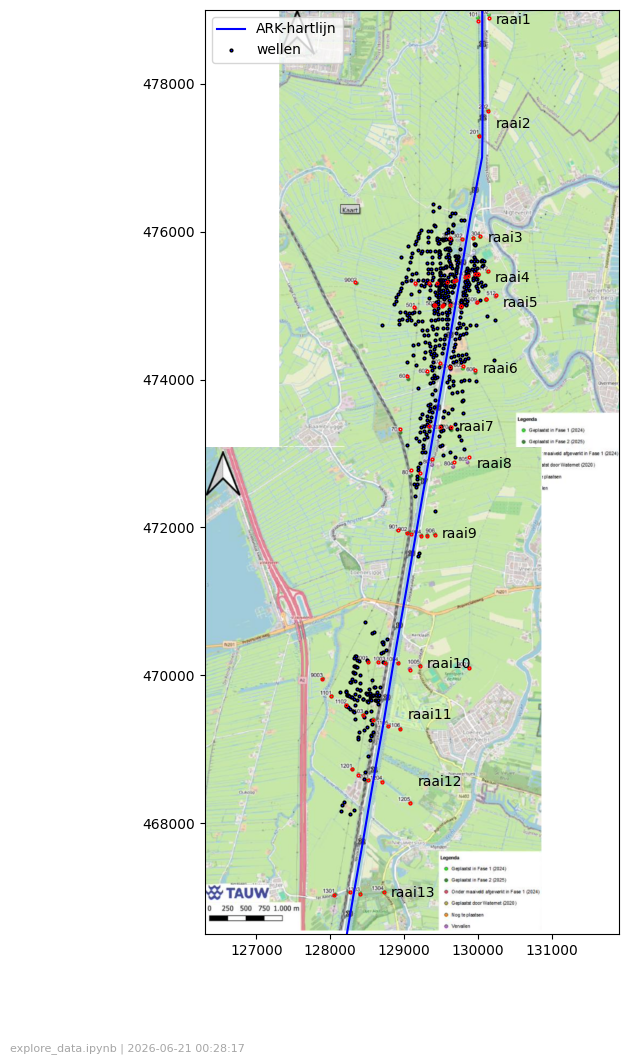

In [43]:
fig, ax = plt.subplots(figsize=(8,12))

ims = [1, 3]

for im in ims[::-1]:
    extent = list(map(float, re.findall(r'\d+', maps[im])))

    img = Image.open(os.path.join(dirs.pb_imag, maps[im]))
    ax.imshow(img, extent=extent, origin='upper')

pbxy = atools.Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')
wellen = picklefrom(os.path.join(dirs.data, 'wellen_deltares_df.pkl'))

hartlijn_ARK = picklefrom(os.path.join(dirs.data, 'hartlijn_ARK.pkl'))

ax.plot(hartlijn_ARK[:,0], hartlijn_ARK[:,1], 'b', label='ARK-hartlijn')

ax.plot(wellen['x'], wellen['y'], 'bo', ms=2, mec='k', label='wellen')

pbxy.plot(ax, mec='r', mfc='none', ms=2)
pbxy.put_raai_names(ax, ha='left', va='center')

ax.set_ylim(466500, 479000)
ax.set_aspect(1)

# ax.set_title(f"File: '{maps[im]}'", fontsize=10)
ax.legend()

for pb in pbxy.data.index:
    rec = pbxy.data.loc[pb]
    # ax.plot([rec['x'], rec['xhit']], [rec['y'], rec['yhit']], 'k')

logo(fig, NOTEBOOK_NAME)
if 0 in ims:
    fig.savefig(os.path.join(dirs.images, "peilgeb_pb.png"))
if 2 in ims:
    fig.savefig(os.path.join(dirs.images, "ligging_dsn_Deltares.png"))
if 3 in ims:
    fig.savefig(os.path.join(dirs.images, "peilb+wellen.png"))

    


Loaded <function basename at 0x107c7f9c0> <-- /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/wellen_deltares_df.pkl


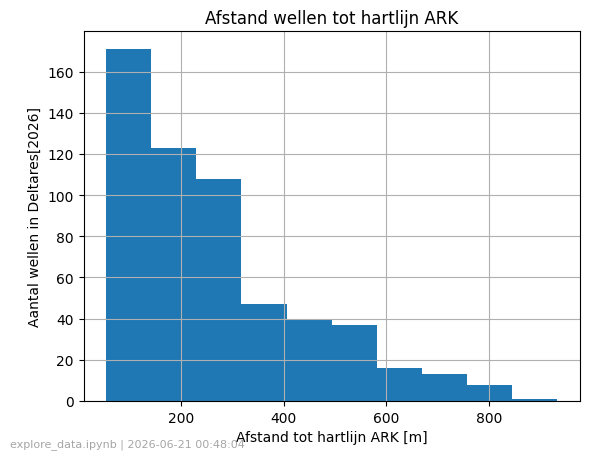

In [49]:
wellen = picklefrom(os.path.join(dirs.data, 'wellen_deltares_df.pkl'))

plt.hist(wellen['dist'])
plt.title('Afstand wellen tot hartlijn ARK')
plt.ylabel('Aantal wellen in Deltares[2026]')
plt.xlabel('Afstand tot hartlijn ARK [m]')
plt.grid()
fig = plt.gcf()
logo(fig, NOTEBOOK_NAME)
fig.savefig(os.path.join(dirs.images, "wellen_deltares_hist.pdf"))

# Distance wellen to ARK hartlijn

First get the meta data for the piezometers, which contains the row (raai) info.

Then define the y-range pertaining to each raai yielding a DataFrame with raai and y_mean, y_max and y_min
coordinates.

Then get the wellen in a DataFrame.

Add the column raai to it. For each point the raai is determined from the coordinate falling in a raai-range in the raaien DataFrame.

Pandas as a special trick for this, provide by chatgpt.

In [99]:
# --- Get the wellen
wellen_ = picklefrom(os.path.join(dirs.data, "wellen.pkl"))
wellen = pd.DataFrame(wellen_)
wellen.columns = ['x', 'y']
wellen.index.name = 'id'
wellen

# --- Add distance to ARK and xhit, yhit (perpendicular lines)
dist, pnts_hit = point_polyline_distance(wellen_, hartlijn_ARK)
wellen['dist'] = np.round(dist, 1)
wellen['xhit'] = pnts_hit.T[0].round(1)
wellen['yhit'] = pnts_hit.T[1].round(1)
wellen

Loaded <function basename at 0x101fe39c0> <-- /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/wellen.pkl


,x,y,dist,xhit,yhit
id,,,,,
0,129398.0,476168.0,485.6,129876.8,476087.1
1,129405.0,476105.0,468.2,129866.7,476027.0
2,129602.0,476057.0,266.0,129864.3,476012.7
3,129598.0,476032.0,265.8,129860.1,475987.7
4,129570.0,475998.0,287.7,129853.7,475950.1
...,...,...,...,...,...
116,129701.0,474153.0,151.1,129552.1,474178.8
117,129759.0,474169.0,205.5,129556.5,474204.1
118,129837.0,474184.0,279.8,129561.3,474231.7


# Raaien (piezometer transects)

In [ ]:
# --- get the meta data
pbxy = atools.Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')
pb_meta = pbxy.data

# --- Generate the raaien DataFrame
Y = {}
# --- Get the existing raaien from the pd_meta DataFrame
for raai in np.unique(pb_meta['raai'].values):
    # --- the mean y for all piezometers belonging to a raai
    y = pb_meta.loc[pb_meta['raai']==raai, 'y'].mean()
    Y[int(raai)] = {'mean':float(y.mean().round())} 
    
# --- Add a virtual raai above and below the  existing ones
Y[ 0] = {'mean':Y[ 1]['mean'] + 250}
Y[14] = {'mean':Y[13]['mean'] - 250}

# --- Reorder the keys
for k in sorted(Y.keys()):
    Y[k] = Y.pop(k)
 
 # --- Get the min and max y for all raaien except the virtual ones
for k in list(Y.keys())[1:-1]:
    Y[k]['max'] =  (Y[k]['mean'] + Y[k-1]['mean']) / 2
    Y[k]['min']  = (Y[k]['mean'] + Y[k+1]['mean']) / 2

# --- Print the results except the virtual ones
for k in list(Y.keys())[1:-1]:
    # print(f"{k},{Y[k]['mean']},{Y[k]['max']},{Y[k]['min']}")
    pass
    
# --- Generate the DataFrame
raaien = pd.DataFrame(Y).T
raaien.index.name = "raai"

# --- Remove the virtual raaien
raaien = raaien.loc[raaien.index[1:-1]]
raaien

In [ ]:
import pandas as pd

# Create intervals [min, max)
intervals = pd.IntervalIndex.from_arrays(
    raaien['min'],
    raaien['max'],
    closed='left'
)

# Find the interval containing each y coordinate
wellen['raai'] = raaien.index[intervals.get_indexer(wellen['y'])]

# --- Sort wellen by 'raai' and then by 'dist'
wellen = wellen.sort_values(['raai', 'dist'])

# --- Redifine the index
wellen.index = np.arange(len(wellen))
wellen

pickleto(wellen, os.path.join(dirs.data, "wellen_df.pkl"))

# Temperatuur ARK-water

{'max': {'fr': 0.95, 'temp': 22.9}, 'summer': {'fr': 0.75, 'temp': 18.9}, 'mean': {'fr': 0.5, 'temp': 14.1}, 'winter': {'fr': 0.25, 'temp': 8.6}, 'min': {'fr': 0.03, 'temp': 5.1}}


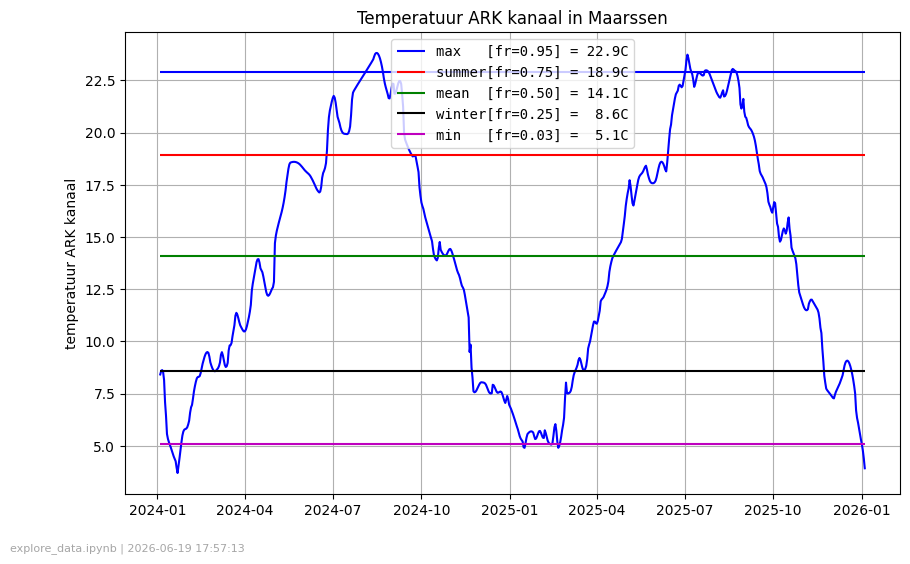

Pickled <function basename at 0x101fe39c0> --> /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/temp_ARK.pkl
Pickled <function basename at 0x101fe39c0> --> /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/temp_ARK_stats.pkl


In [118]:

temp_ARK = pd.read_csv(os.path.join(dirs.pb_data, "tempARK_maarssen.csv"),
                       parse_dates=[0])

# --- Make time increasing everywhere
t = (temp_ARK['datetime'] - temp_ARK.loc[0, 'datetime']) / np.timedelta64(1, 'D')
idx = np.array([0])
while len(idx > 0):
    idx =np.where(np.diff(temp_ARK['datetime']) <= 0)[0]
    temp_ARK = temp_ARK.drop(temp_ARK.index[idx], axis=0)
# --- Prepare for interpolation
t_ark = (temp_ARK['datetime'] - temp_ARK.loc[0, 'datetime']) /np.timedelta64(1, 'D')
T_ark = (temp_ARK['temp']).values

# --- Interpolation points (daily values equidistant)
datetime = np.arange(np.datetime64("2024-01-04"),
               np.datetime64("2026-01-05"),
               np.timedelta64(1, 'D'))

# --- Interpolation time in days since start of datetime
t = (datetime - datetime[0]) / np.timedelta64(1, 'D')
interp = Akima1DInterpolator(t_ark, T_ark)
yy = interp(t)

# --- pd.Dataframe cleaned up
temp_ARK = pd.DataFrame(data=yy, index=datetime, columns=['temp'])
temp_ARK.index.name = 'datetime'

# --- Stats
txt = ['min', 'winter', 'mean', 'summer', 'max'][::-1]
frs = [0.03, 0.25, 0.5, 0.75, 0.95][::-1]
temp_ARK_stats = {t: {'fr':f, 'temp':float(round(np.quantile(yy, f),1))}
                  for t, f in zip(txt, frs)}
print(temp_ARK_stats)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(temp_ARK.index, temp_ARK['temp'], 'b', label='')  # 'temp ARK Maarssen')
clrs = color_cycler()
for i, (key, item) in enumerate(temp_ARK_stats.items()):
    clr = next(clrs)
    x1, x2 = datetime[0], datetime[-1]
    ax.hlines(item['temp'], datetime[0], datetime[-1], colors=clr,
              label=f"{key:6}[fr={item['fr']:.2f}] = {item['temp']:4.1f}C")

ax.set_ylabel("temperatuur ARK kanaal")
ax.set_title("Temperatuur ARK kanaal in Maarssen")
ax.legend(prop={'family':'monospace'})
ax.grid(True)
logo(fig, NOTEBOOK_NAME)
fname = "temp_ARK.pdf"
fig.savefig(os.path.join(dirs.images, fname))
plt.show()

# pickling ARK temperature
pickleto(temp_ARK, os.path.join(dirs.data, 'temp_ARK.pkl'))
pickleto(temp_ARK_stats, os.path.join(dirs.data, 'temp_ARK_stats.pkl'))


# Heads and temps Beemster e.a. fig 9.1

Pickled <function basename at 0x107c7f9c0> --> /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/temp_head_beemster_fig_91.pkl
Pickled <function basename at 0x107c7f9c0> --> /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/temp_head_beemster_fig_91_df.pkl


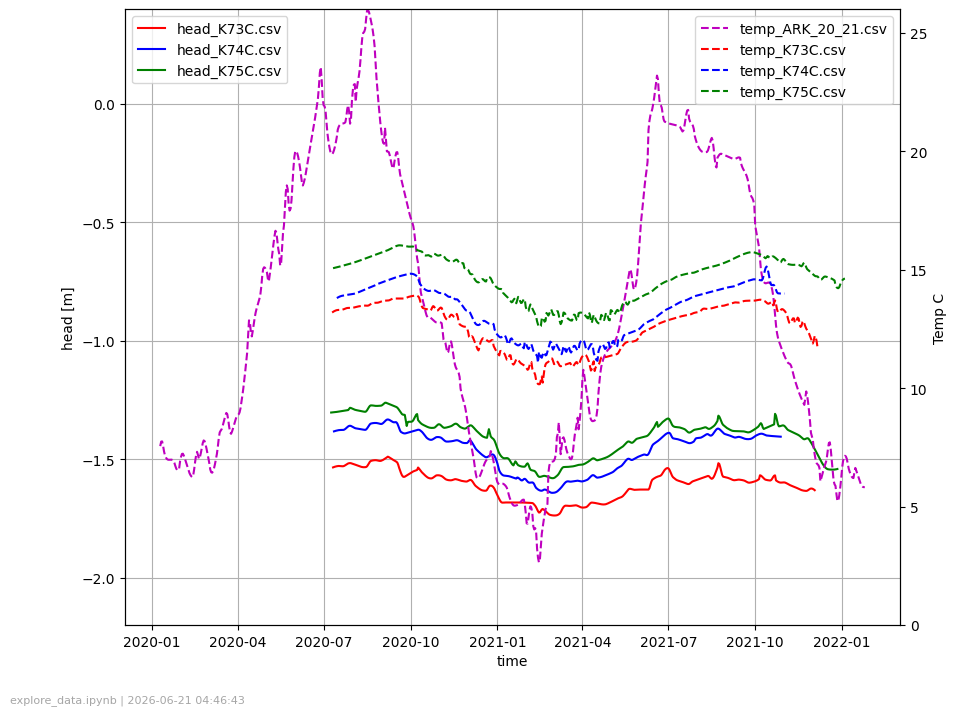

In [163]:
files = sorted(([dirs.data + '/temp_ARK_20_21.csv'] +
         glob(dirs.data + '/head_K7?C.csv') +
         glob(dirs.data + '/temp_K7?C.csv'))         
)

# --- To store the to dayvalues interpolated data
series = dict()


fig, axH = plt.subplots(figsize=(10, 8))
axH.set_xlabel('time')
axH.set_ylabel('head [m]')
axH.grid('both')

axT = axH.twinx()
axT.set_ylabel('Temp C')
axH.grid()

clrs = color_cycler('rbgmkc')
kind = None

for path in files:
    basename = os.path.basename(path)
    
    if 'ARK' in basename:
        clr = 'm'
        kind = 'ARK'
    elif basename.startswith('temp'):
        if kind != 'temp':
            clrs = color_cycler('rbgmkc')
            kind = 'temp'
    elif basename.startswith('head'):
        if kind != 'head':
            clrs = color_cycler('rbgmkc')
            kind = 'head'
    if kind != 'ARK':
        clr = next(clrs) 
 
    data = pd.read_csv(path, parse_dates=[0])
    data.columns=['datetime', kind if kind is not None else 'temp']
    
    data.index = data['datetime']
    data = data.drop(['datetime'], axis=1)
    data.index.name = 'datetime'
    data = data.sort_index() # --- Index was not sorted
    
    # --- Interpolate the data    
    d_start = data.index[ 0].floor('D') + np.timedelta64(1, 'D')
    d_end   = data.index[-1].floor('D') + np.timedelta64(1, 'D')

    # --- The old data (raw digitized)    
    t_old = (data.index - data.index[0]) / np.timedelta64(1, 'D')
    v_old = data[kind].values
    if kind == 'head':
        # --- I digitized the heads on the temp axies. Rescale to match h-axis
        v_old = -2.2 + v_old / 26 * (0.4 + 2.2)
        
    idx = np.where(t_old[1:] > t_old[:-1])[0]
    if len(idx) > 0:
        t_old = t_old[idx]
        v_old = v_old[idx]

    # --- New index are dayly dates
    index = np.arange(d_start, d_end, np.timedelta64(1, 'D'))
    
    t = (index - index[0]) / np.timedelta64(1, 'D')

    interp = Akima1DInterpolator(t_old, v_old)
    v = interp(t)

    # --- Store in series dict 
    s = pd.Series(v, index=index)
    s = s.dropna()   
    series[basename] = s     
    if kind == 'head':
        shift = 0. # 0.65
        axH.plot(s.index, s.values + shift, color=clr, label=basename)
    else:        
        axT.plot(s.index, s.values, '--', color=clr, label=basename)
axH.grid(True) 
axH.set_ylim(-2.2, 0.4)
axT.set_ylim(0, 26)
axH.legend(loc='upper left')
axT.legend(loc='upper right')

pickleto(series, os.path.join(dirs.data, 'temp_head_beemster_fig_91.pkl'))
pickleto(series, os.path.join(dirs.data, 'temp_head_beemster_fig_91_df.pkl'))

logo(fig, NOTEBOOK_NAME)
fig.savefig(os.path.join(dirs.images, 'temp_head_beemster_fig91.pdf'))



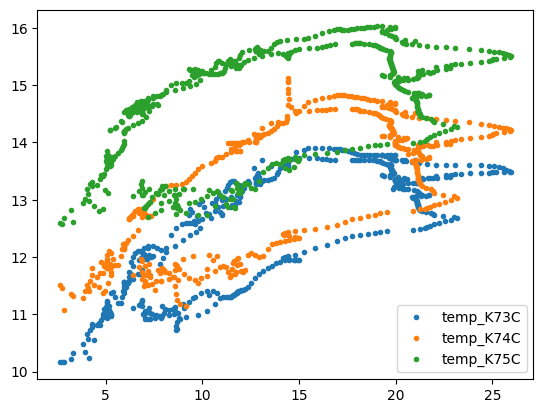

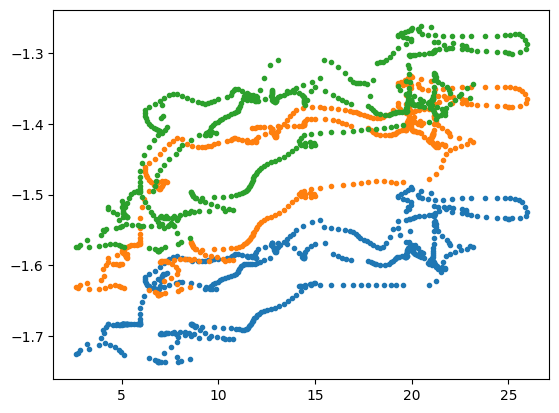

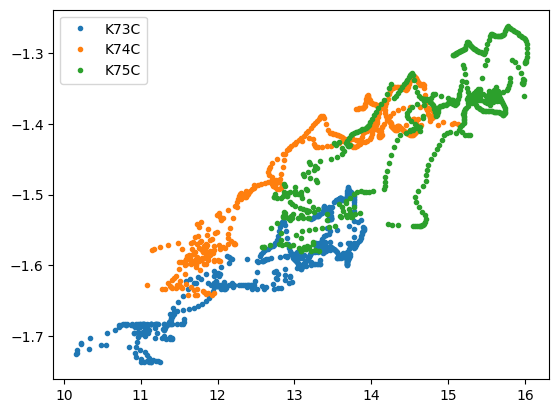

In [154]:
series_df = pd.DataFrame()
for key, s in series.items():
    k = key[:-4]
    series_df[k] = series[key]
series_df

fig, ax = plt.subplots()
for k in ['temp_K73C', 'temp_K74C','temp_K75C']:
    ax.plot(series_df['temp_ARK_20_21'], series_df[k], '.', label=k)

ax.legend()

fig, ax = plt.subplots()
for k in ['head_K73C', 'head_K74C','head_K75C']:
    ax.plot(series_df['temp_ARK_20_21'], series_df[k], '.', label=k)

fig, ax = plt.subplots()
for k in ['K73C', 'K74C','K75C']:
    ax.plot(series_df['temp_' + k], series_df['head_' + k], '.', label=k)

ax.legend()

In [126]:
series.keys()

dict_keys(['temp_ARK_20_21.csv', 'head_K73C.csv', 'head_K75C.csv', 'head_K74C.csv', 'temp_K73C.csv', 'temp_K75C.csv', 'temp_K74C.csv'])

# Plot heads en temperatures of all rows (as far as as data is available)

Date obtained using webplotdigitizer from the figure in Deltares report:
"Systeemanalyze, concept maart 2026".

/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a,

pb406, WE=W, dist=   3 m, T_min=12.3, T_max=17.0, t[T_min]=2025-06-28 20:23:59, T[T_max]=2025-12-08 05:28:39
pb407, WE=E, dist=  19 m, T_min=12.0, T_max=19.0, t[T_min]=2025-06-28 05:17:41, T[T_max]=2025-11-09 15:27:40
pb506, WE=W, dist=  28 m, T_min=12.8, T_max=nan, t[T_min]=2025-06-26 23:28:22, T[T_max]=2025-01-17 18:26:53
pb508, WE=E, dist=  24 m, T_min=14.2, T_max=17.4, t[T_min]=2025-11-12 10:00:39, T[T_max]=2025-07-08 20:23:39


/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a,

Month-averaged head around the 3 dates given min, max and min values
pb1,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.322
pb2,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.376
pb3,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.144
pb4,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.403
pb5,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.382
pb6,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.502
pb7,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.489
pb8,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.565
pb9,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.481
pb10,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.559
pb101,2025-01-25,2025-08-01,2026-02-01,nan,-1.692,-1.78
pb102,2025-01-25,2025-08-01,2026-02-01,nan,-1.739,-1.841
pb201,2025-01-25,2025-08-01,2026-02-01,nan,-1.481,-1.684
pb202,2025-01-25,2025-08-01,2026-02-01,nan,-1.49,-1.7
pb301,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.654
pb302,2025-01-25,2025-08-01,2026-02-01,nan,-1.235,-1.556
pb303,2025-01-25,2025-08-01,2026-02-01,nan,-1.116,nan
pb304,2025-01-25,2025

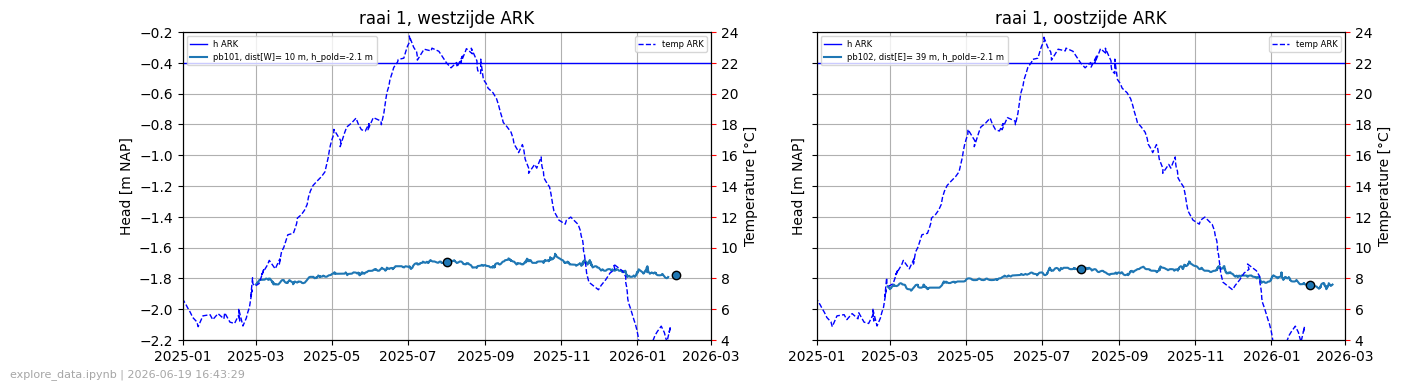

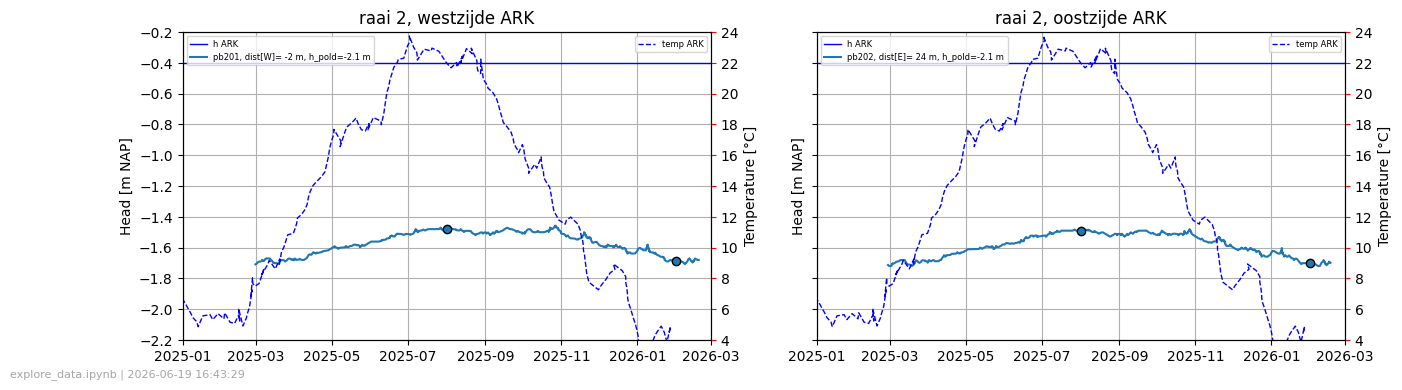

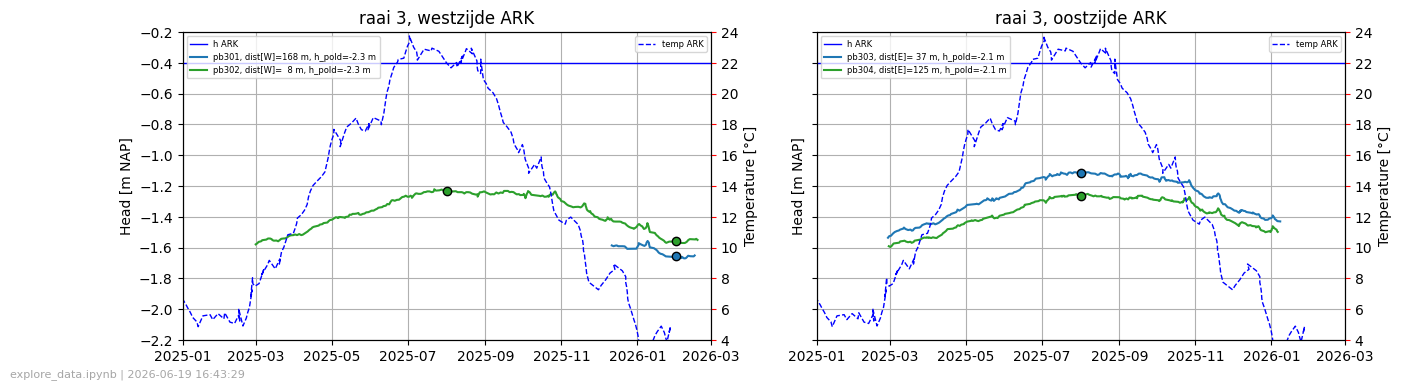

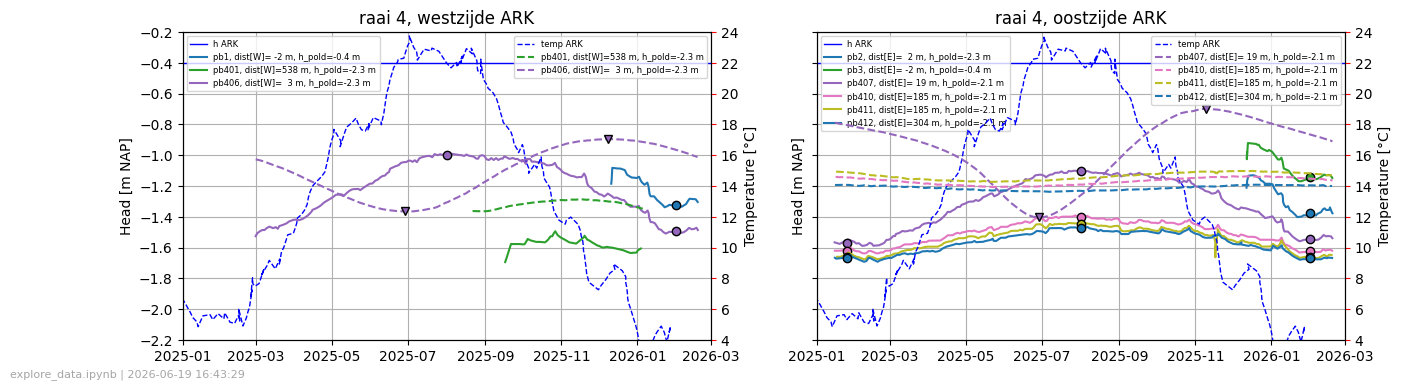

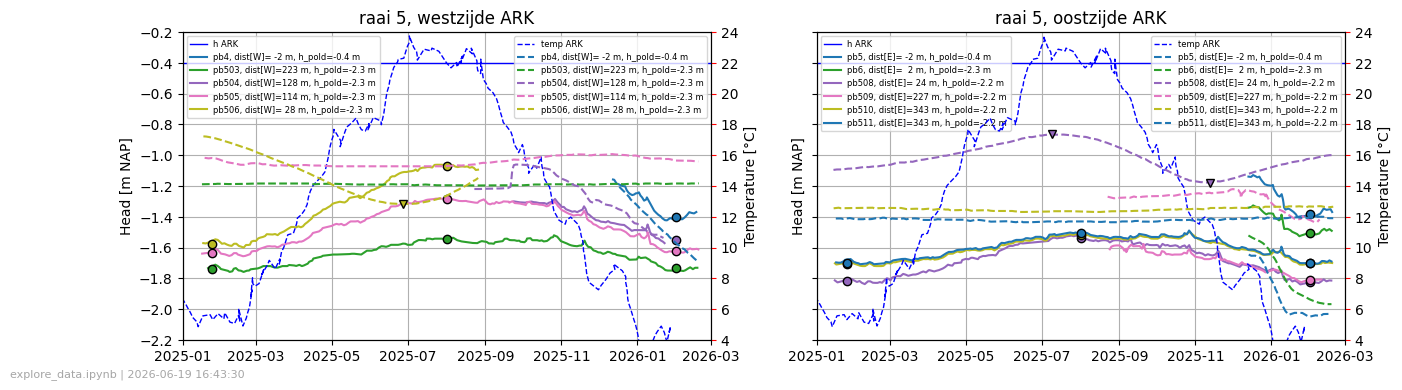

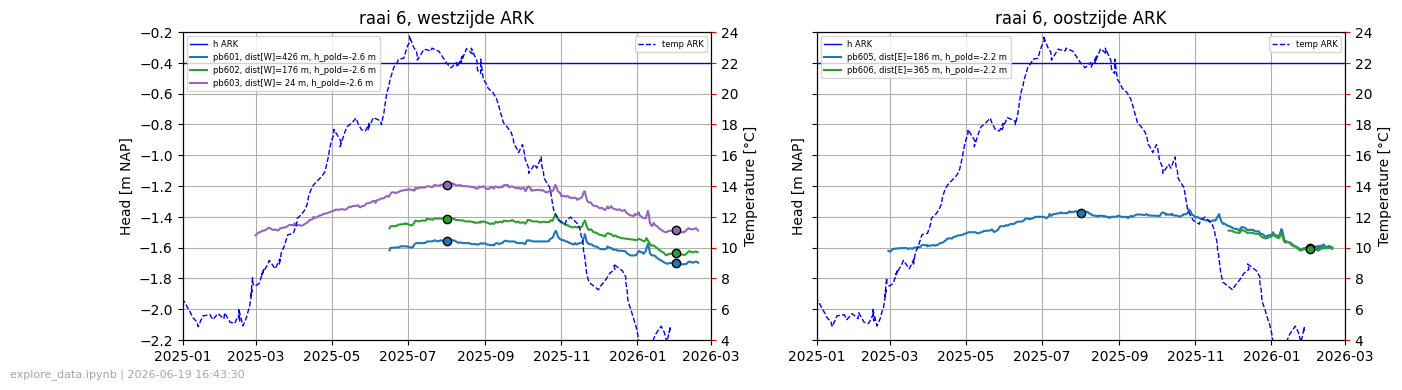

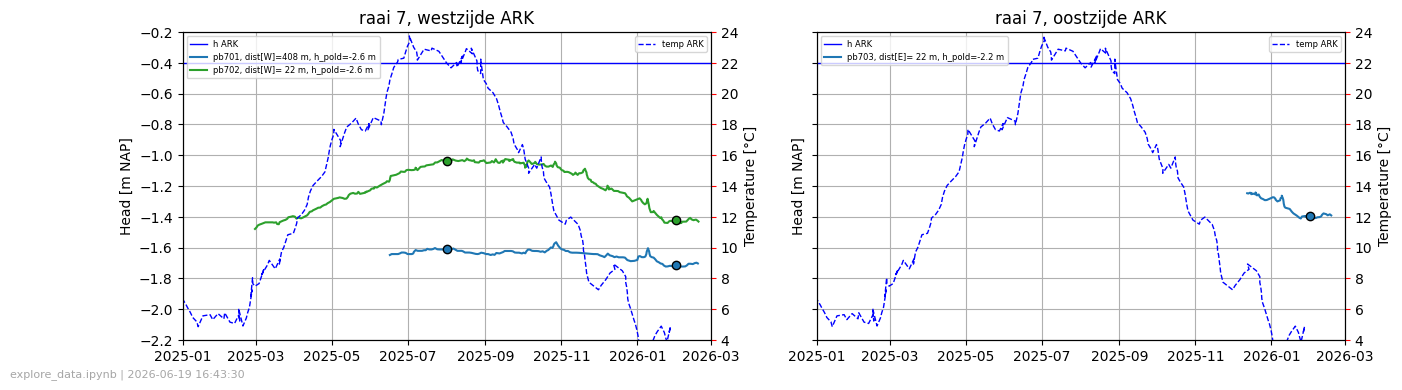

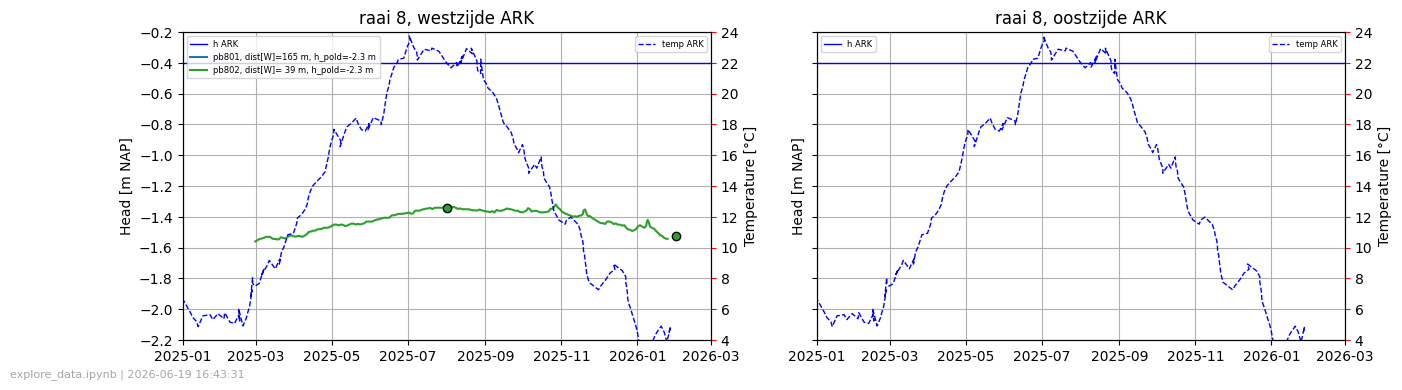

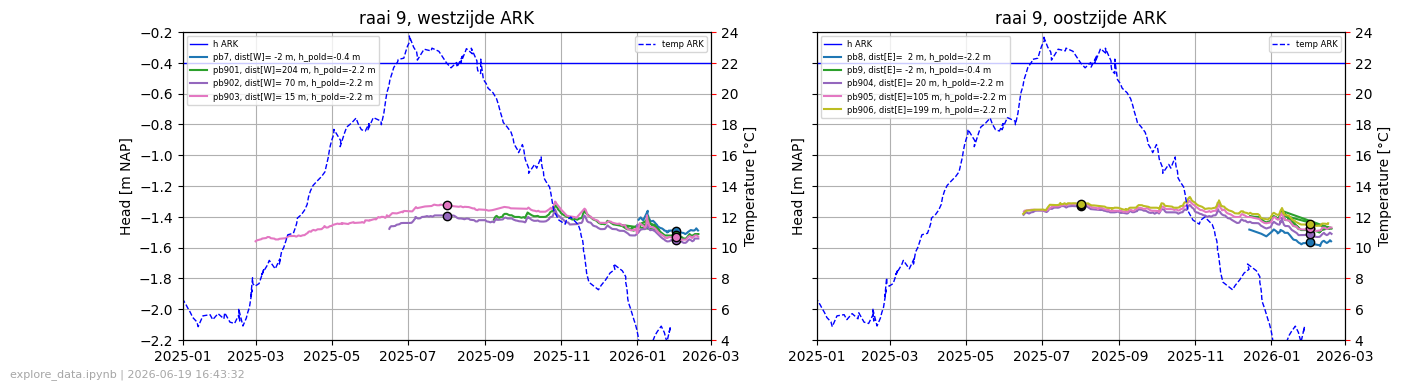

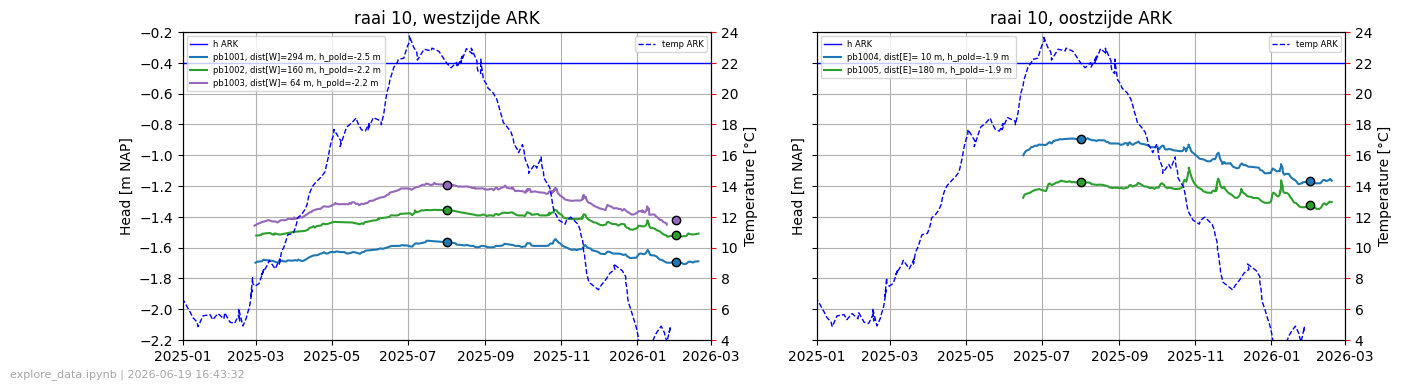

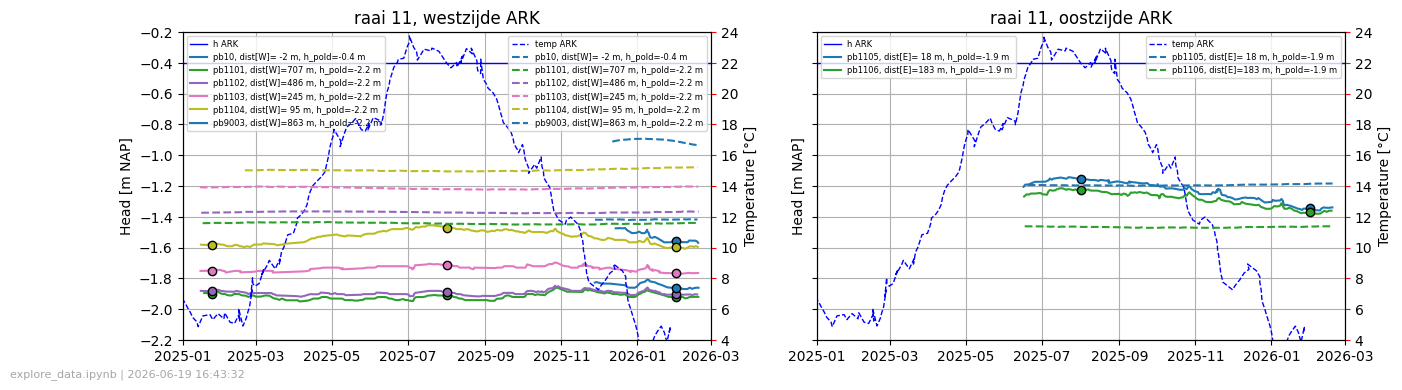

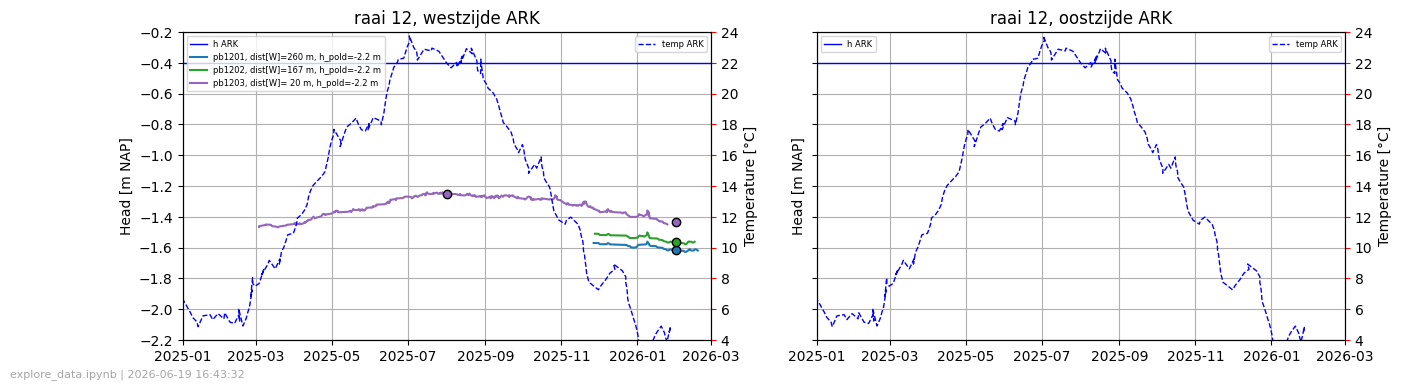

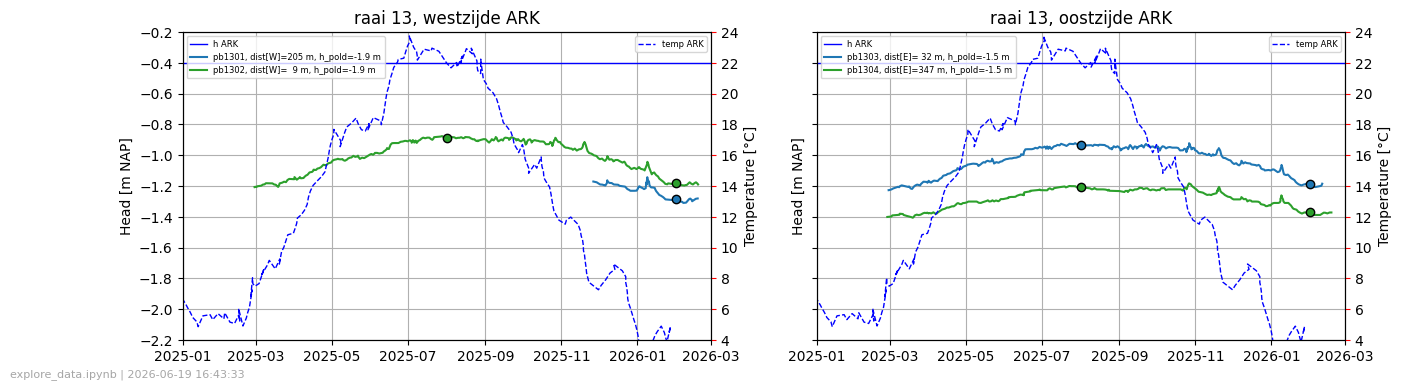

In [97]:
pbxy = atools.Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')
pbkan = atools.Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbKanaal')

# --- pd.DataFrame
pb_tauw_meta   = pbxy.data
pb_kanaal_meta = pbkan.data

b_ARK = 50

# --- Get ARK temperature
temp_ark = pd.read_csv(os.path.join(dirs.pb_data, 'tempARK_maarssen.csv'),
                       index_col=0, parse_dates=True)
temp_ark.columns=['temp']
temp_ark.index.name = 'datetime'


# --- Get dictionary with one fig for every row with 2 head and 2 overlapping temp axes
figaxs = {}
for raai in range(1, 14):
    fig, (axW, axE) = plt.subplots(1, 2, figsize=(15, 4), sharex=True, sharey=True)
    
    # logo(fig, NOTEBOOK_NAME)
    
    axW.set_title(f"raai {raai}, westzijde ARK")
    axE.set_title(f"raai {raai}, oostzijde ARK")
        
    xlim = (np.datetime64("2025-01-01"), np.datetime64("2026-03-01"))            
    axW.set_xlim(xlim)
    axE.set_xlim(xlim)
    
    ticks_h    = np.linspace(-2.2, -0.2, 11)
    ticks_temp = np.linspace(4, 24, 11)
    lim_h    = ticks_h[[0, -1]]
    lim_temp = ticks_temp[[0, -1]]
    
    axW.set_ylim(lim_h)
    axE.set_ylim(lim_h)
 
    axWT = axW.twinx()
    axET = axE.twinx()
    
    axET.set_ylabel("temp")
        
    axWT.set_ylim(lim_temp)
    axET.set_ylim(lim_temp)

    axW.set_yticks(ticks_h)
    axE.set_yticks(ticks_h)
    
    axWT.set_yticks(ticks_temp)
    axET.set_yticks(ticks_temp)
    
    axW.grid(True)
    axE.grid(True)
    
    axWT.tick_params(axis='y', color='red')
    axET.tick_params(axis='y', color='red')
    
    axW.set_ylabel('Head [m NAP]')
    axE.set_ylabel('Head [m NAP]')
    axWT.set_ylabel('Temperature [°C]')
    axET.set_ylabel('Temperature [°C]')
    
    h_ARK = -0.4
    axW.plot(xlim, [h_ARK, h_ARK], '-', color='blue', lw=1, label="h ARK") 
    axE.plot(xlim, [h_ARK, h_ARK], '-', color='blue', lw=1, label="h ARK")
    axWT.plot(temp_ark.index, temp_ark.loc[:, 'temp'], '--', color='blue', lw=1, label='temp ARK')
    axET.plot(temp_ark.index, temp_ark.loc[:, 'temp'], '--', color='blue', lw=1, label='temp ARK')

    figaxs[raai] = {'fig': fig, "axW":axW, "axE":axE, "axWT":axWT, "axET":axET}
    
Y = {}

# ---- Get data from these files, determine its row and plot head and temperature on the correct row head and temp axes
for fbn in [ 'pb[0-9].csv', 'pb10.csv', 'pb1[0-9][0-9].csv', 'pb2[0-9][0-9].csv', 'pb3[0-9][0-9].csv', 'pb4[0-9][0-9].csv',
            'pb5[0-9][0-9].csv', 'pb6[0-9][0-9].csv', 'pb7[0-9][0-9].csv', 'pb8[0-9][0-9].csv',
            'pb9[0-9][0-9].csv', 'pb10[0-9][0-9].csv', 'pb11[0-9][0-9].csv',
            'pb12[0-9][0-9].csv', 'pb13[0-9][0-9].csv', 'pb900[0-9].csv']:
    
    # --- current list of csv data files
    pb_csv_files = sorted(glob(os.path.join(dirs.pb_data, fbn)))

    # --- for each piezometer data csv file
    for fname in pb_csv_files:
        basename = os.path.basename(fname)        
        pb_idx = int(re.findall(r"(\d+)\.csv", basename)[0])
        pb_name = basename[:-4]
        try:
            # --- Normal drilled piezometer
            rec = pb_tauw_meta.loc[pb_idx]
        except Exception:
            # --- Then a sounding piezometer (not drilled) in or next to the ARK
            rec = pb_kanaal_meta.loc[pb_idx]
          
        # --- Specifics for this piezometer  
        raai = rec['raai']
        dist = rec['dist'] - b_ARK
        WE   = rec['WE']
        VP   = (rec['ZP'] + rec['WP']) / 2
                
        # --- knowing the row of this piezometer, get the correct figure and axes
        fig, axW, axE, axWT, axET = (figaxs[raai]['fig'],
                                     figaxs[raai]['axW'], figaxs[raai]['axE'],
                                     figaxs[raai]['axWT'], figaxs[raai]['axET'])
        
        # --- get the head data
        pb = pd.read_csv(fname, header=None, parse_dates=True, index_col=0)
        pb.columns=['h']
        pb.index.name = 'datetime'
        
        t = pb.index
        y = pb.loc[:, 'h'].values
        
        # --- we want the min and max (average over 1 month around occuring dates)
        mask1 = np.logical_and(t>np.datetime64("2025-01-01"), t < np.datetime64("2025-02-20"))
        mask2 = np.logical_and(t>np.datetime64("2025-07-15"), t < np.datetime64("2025-08-15"))
        mask3 = np.logical_and(t>np.datetime64("2026-01-15"), t < np.datetime64("2026-03-01"))
        
        # --- Get these special values
        y1 = np.round(np.median(y[mask1]), 3)
        y2 = np.round(np.median(y[mask2]), 3)
        y3 = np.round(np.median(y[mask3]), 3)
        # print(f"{pb_name[:-4]:6} {raai} {y1}, {y2}, {y3}")
        
        # --- Store these data in dict
        tt = [np.datetime64("2025-01-25"), np.datetime64("2025-08-01"), np.datetime64("2026-02-01")]
        Y[pb_name] ={'t':tt, 'h':[y1, y2, y3]}
        
        # --- Is this piezometer located to the west or the east of the ARK canal?
        # --- Use correct axes
        if WE=='W':
            ax=axW
        else:
            ax=axE
        # --- plot time series
        ln, = ax.plot(t, y, label=f"{pb_name}, dist[{WE}]={dist:3.0f} m, h_pold={VP:.2} m")
        clr = ln.get_color()

        # --- special points
        ax.plot(tt, [y1, y2, y3], 'o', mfc=clr, mec='k')
        
        # --- Second part, add temperature
        # --- same name but "temp_" prepended
        fname_temp = os.path.join(dirs.pb_data, f'temp_pb{pb_idx}.csv')
        try:
            pb_temp = pd.read_csv(fname_temp, header=None, parse_dates=True, index_col=0)
            pb_temp.columns=['temp']
            pb_temp.index.name = 'datetime'
        except FileNotFoundError:
            # --- if the temp .csv file does not exist for this piezometer, skip it
            continue
        
        # --- Plot the temperature time series on the correct axes and with same color as the head
        t_temp = pb_temp.index
        y_temp = pb_temp.loc[:, 'temp'].values
        
        if WE=='W':
            ax=axWT
        else:
            ax=axET
        ax.plot(t_temp, y_temp, '--', color=clr, label=f"{basename[:-4]}, dist[{WE}]={dist:3.0f} m, h_pold={VP:.2} m")
        
        if pb_name in ['pb406', 'pb407', 'pb506', 'pb508']:
            i_T_max = np.argmax(y_temp)
            i_T_min = np.argmin(y_temp)
            T_min = y_temp[i_T_min]
            T_max = y_temp[i_T_max]
            t_min = t_temp[i_T_min]
            t_max = t_temp[i_T_max]
            if pb_name == 'pb506':
                T_max = np.nan                
            ax.plot(t_min, T_min, 'v', mfc=clr, mec='k')
            ax.plot(t_max, T_max, 'v', mfc=clr, mec='k')
            print(f"{pb_name}, WE={WE}, dist={dist:4.0f} m, T_min={T_min:.1f}, T_max={T_max:.1f}, t[T_min]={t_min}, T[T_max]={t_max}")


# --- Finally set the legends for all axes
for raai, figax in figaxs.items():    
    figax['axW'].legend(loc='upper left', fontsize=6)
    figax['axE'].legend(loc='upper left', fontsize=6)
    figax['axWT'].legend(loc='upper right', fontsize=6)
    figax['axET'].legend(loc='upper right', fontsize=6)
    
    logo(figax['fig'], NOTEBOOK_NAME)
    
    fname = f"tijdr_raai{raai}.pdf"
    figax['fig'].savefig(os.path.join(dirs.images, fname))
    
    
print("Month-averaged head around the 3 dates given min, max and min values")
for fn, data in Y.items():
    print(f"{fn},{data['t'][0]},{data['t'][1]},{data['t'][2]},{data['h'][0]},{data['h'][1]},{data['h'][2]}")

In [ ]:
for raai, figax in figaxs.items():
    save_name = f"h_temp_raai{raai}.pdf"
    fig_path = os.path.join(dirs.images, save_name)    
    figax['fig'].savefig(fig_path)
    print(f"fig raai {raai} saved to: {fig_path}")
        
# pb, t, y

# Vergelijking gemeten zomer stijghoogten met de vanuit de winterstijghoogten berekende zomerwaarden.

In [103]:
pb = pd.DataFrame()
pb_meta = pb_meta.astype(dtype={'raai':int, 'dist':float, 'summer':float, 'winter':float, 'ZP':float, 'WP':float})
for raai in range(14):
    pb = pd.concat((
        pb, pb_meta[['raai', 'dist', 'summer', 'winter', 'ZP', 'WP']][(pb_meta['raai']==raai) & (pb_meta['dist'] < 200.) & (pb_meta['WE']=='W') & (pb_meta['summer'] !=0.) & (pb_meta['winter'] !=0.)])
    )
pb['Z-W']=pb['summer'] - pb['winter']
pb['sum'] = np.nan

  name  h_ARK    hTr     hp      T Tr     mu_rat  q_rat    hT1    hT2     hT hT-hT2
   101 -0.400 -1.780 -2.000  22.90  5.100  0.625  1.478 -1.675 -1.675 -1.692 -0.017
   201 -0.400 -1.684 -2.000  22.90  5.100  0.625  1.430 -1.548 -1.548 -1.481  0.067
   302 -0.400 -1.556 -2.300  22.90  5.100  0.625  1.296 -1.336 -1.336 -1.235  0.101
   406 -0.400 -1.490 -2.300  22.90  5.100  0.625  1.274 -1.268 -1.268 -0.998  0.270
   505 -0.400 -1.622 -2.300  22.90  5.100  0.625  1.318 -1.407 -1.407 -1.285  0.122
   603 -0.400 -1.485 -2.600  22.90  5.100  0.625  1.227 -1.232 -1.232 -1.196  0.036
   702 -0.400 -1.424 -2.600  22.90  5.100  0.625  1.211 -1.175 -1.175 -1.036  0.139
   802 -0.400 -1.524 -2.330  22.90  5.100  0.625  1.279 -1.299 -1.299 -1.341 -0.042
   902 -0.400 -1.551 -2.250  22.90  5.100  0.625  1.304 -1.338 -1.338 -1.395 -0.057
   903 -0.400 -1.531 -2.250  22.90  5.100  0.625  1.297 -1.317 -1.317 -1.325 -0.008
  1003 -0.400 -1.423 -2.300  22.90  5.100  0.625  1.253 -1.201 -1.201 -1.193

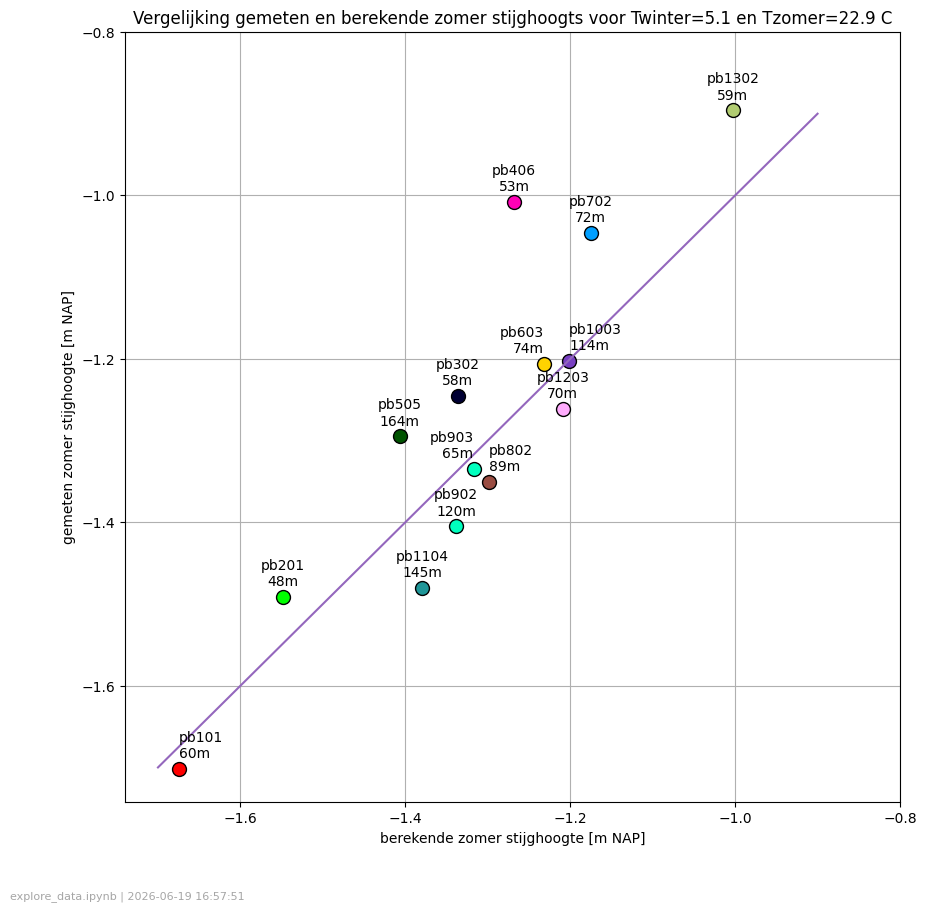

In [104]:
Tr, T = temp_ARK_stats['winter']['temp'], temp_ARK_stats['summer']['temp']
Tr, T = temp_ARK_stats['min']['temp'], temp_ARK_stats['max']['temp']

mu_ratio = muT_mu10C(T) / muT_mu10C(Tr)
h_ARK = -0.4

fig, ax = plt.subplots(figsize=(10., 10.))
ax.set_title(f"Vergelijking gemeten en berekende zomer stijghoogts voor Twinter={Tr} en Tzomer={T} C")
ax.set_ylabel("gemeten zomer stijghoogte [m NAP]")
ax.set_xlabel("berekende zomer stijghoogte [m NAP]")

pb['ha'] = 'center'
pb.loc[[603, 903], 'ha'] = 'right'
pb.loc[[101, 802, 1003], 'ha'] = 'left'

print(f"{'name':>6} {'h_ARK':>6} {'hTr':>6} {'hp':>6} {'T':>6} {'Tr':6} {'mu_rat':>6} {'q_rat':>6} {'hT1':>6} {'hT2':>6} {'hT':>6} {'hT-hT2'}")
for i, name in enumerate(pb.index):
    rec = pb.loc[name]
    raai = int(rec['raai'])    
    hp = rec['WP']
    hTr = rec['winter']
    hT  = rec['summer']
    dist = rec['dist']
    q_ratio = (h_ARK - hp) / ((h_ARK - hTr) * mu_ratio + (hTr - hp))
    hT1 = hp + q_ratio * (hTr - hp)
    hT2 = hp + (h_ARK - hp) / ((h_ARK - hTr)/(hTr - hp) * mu_ratio + 1)
    pb.loc[name, 'sum'] = hT2.round(3)
    print(f"{name:>6} {h_ARK:6.3f} {hTr:6.3f} {hp:6.3f} {T:6.2f} {Tr:6.3f} {mu_ratio:6.3f} {q_ratio:6.3f} {hT1:6.3f} {hT2:6.3f} {hT:6.3f} {hT - hT2:6.3f}")
    
    ax.plot(hT2, hT - 0.01, 'o', mfc=atools.leg_colors[raai], ms=10, mec='k', label='name')
    ax.text(hT2, hT, f"pb{name}\n{dist:.0f}m", ha=rec['ha'], va='bottom')

ax.plot([-1.7, -0.9], [-1.7, -0.9])
ax.set_xlim(None, -0.8)
ax.set_ylim(None, -0.8)
ax.grid()

logo(fig, NOTEBOOK_NAME)

fig.savefig(os.path.join(dirs.images, f'ber_vs_gem_zomer_stijghoogen_T{Tr:.0f}_{T:.0f}.pdf'))

plt.show()


In [ ]:
((h_ARK - pb['summer'])/0.05), ((h_ARK - pb['winter']) / 0.025)
muT_mu10C(18.8) * 6, muT_mu10C(8.5) * 6

# Plot all  summer and winter data 

raai4, WE=W, tcol=summer, sum(mask)=1
raai4, WE=W, tcol=winter, sum(mask)=1
raai4, WE=E, tcol=summer, sum(mask)=4
raai4, WE=E, tcol=winter, sum(mask)=4
raai5, WE=W, tcol=summer, sum(mask)=3
raai5, WE=W, tcol=winter, sum(mask)=3
raai5, WE=E, tcol=summer, sum(mask)=3
raai5, WE=E, tcol=winter, sum(mask)=4
raai6, WE=W, tcol=summer, sum(mask)=3
raai6, WE=W, tcol=winter, sum(mask)=3
raai6, WE=E, tcol=summer, sum(mask)=1
raai6, WE=E, tcol=winter, sum(mask)=2


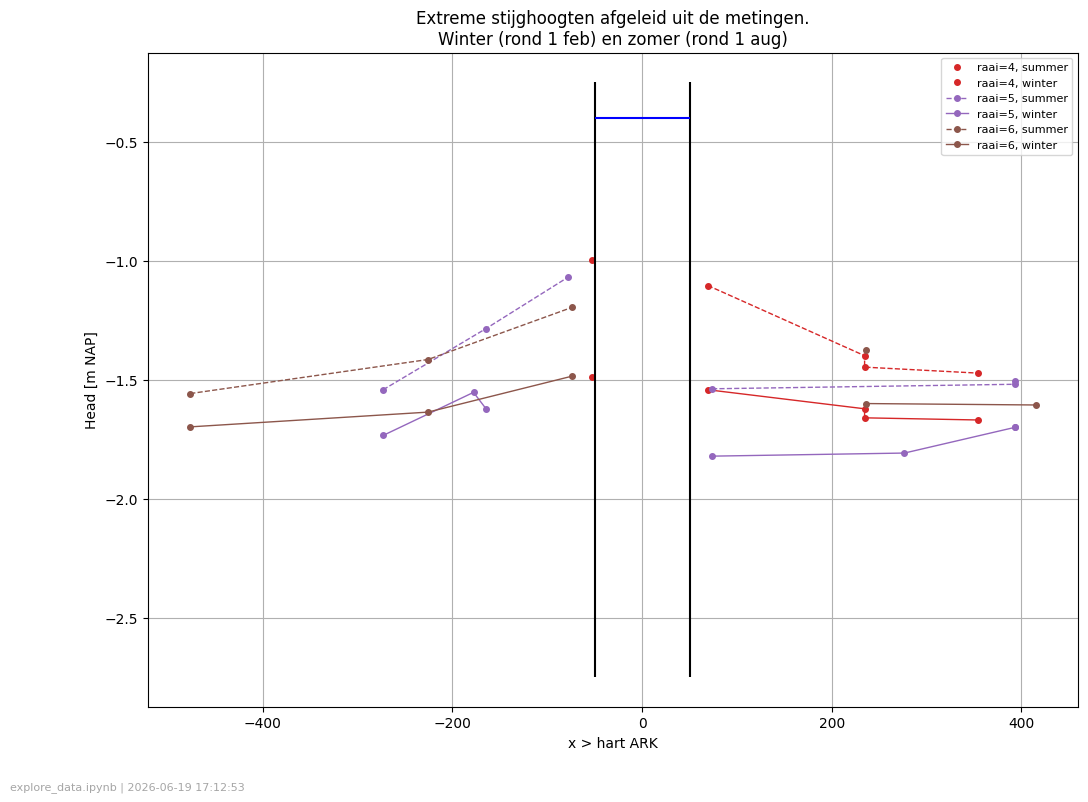

In [114]:
fig, ax = plt.subplots(figsize=(12, 8.5))

ax.set_xlabel('x > hart ARK')
ax.set_ylabel('Head [m NAP]')

# === Add heads measured in cross sections perpendicular to the ARK

for raai in np.unique(pb_meta['raai']):
    if raai not in [4, 5, 6]:
        continue
    for WE in ['W', 'E']:
        for tcol in ['summer', 'winter']:
            mask = (pb_meta['raai'] == raai) & (pb_meta['WE'] == WE) & (pb_meta[tcol] != 0)
            print(f"raai{raai}, WE={WE}, tcol={tcol}, sum(mask)={np.sum(mask)}")
            n = np.sum(mask)
            if n < 1:
                continue
            x = pb_meta.loc[mask, 'dist'].values
            y = pb_meta.loc[mask, tcol].values
            
            if WE == 'W':
                x = -x  # For now all on the positive x-axis
                label=f"raai={raai}, {tcol}"                
            else:
                label=""                
                
            if tcol == 'summer':
                ls = '--'
            else:
                ls = '-'
                            
                
            if n == 1:
                ax.plot(x, y, 'o', ms=4, color=atools.raai_colors[raai - 1], label=label)
                pass
            else:
                if tcol == tcol[1]:
                    lw = 2
                else:
                    lw = 1
                ix = np.argsort(x)
                ax.plot(x[ix], y[ix], marker='o', ms=4, ls=ls, color=atools.raai_colors[raai - 1], lw=lw, label=label)

ax.vlines([-b_ARK, b_ARK], ymin=-2.75, ymax=-0.25, colors=['k'])
ax.hlines([-0.4], xmin=-b_ARK, xmax=+b_ARK, colors='b')

ax.set_title(
    "Extreme stijghoogten afgeleid uit de metingen.\n" +
    "Winter (rond 1 feb) en zomer (rond 1 aug)"
    )
ax.grid(True)
ax.legend(fontsize=8)

logo(fig, NOTEBOOK_NAME)

plt.show()

fname = "stijgh_xs_ark_gemeten.pdf"
fig.savefig(os.path.join(dirs.images, fname))
